# Voyage Multimodal Image Embeddings → MongoDB Atlas → PCA + K-Means

This notebook is a demo-safe version of the Caltech-101 image embedding POC, but with embeddings stored in **MongoDB** instead of a local `.npy` cache.

What it does:

1. Uses real curated Caltech-101 images.
2. Reads your Voyage API key from `.env`.
3. Embeds only missing images to stay friendly for the Voyage free tier.
4. Stores embeddings and metadata in MongoDB.
5. Creates a unique metadata index and attempts to create a MongoDB Atlas Vector Search index.
6. Loads embeddings back from MongoDB.
7. Runs PCA + K-Means and writes cluster IDs/PCA coordinates back to MongoDB.
8. Includes image previews and a vector-search demo.

Expected `.env` values:

```bash
VOYAGEAI_API_KEY=your_voyage_key_here
# or
VOYAGE_API_KEY=your_voyage_key_here

MONGODB_URI=mongodb+srv://<user>:<password>@<cluster-url>/?retryWrites=true&w=majority
MONGODB_DB_NAME=voyage_image_poc               # optional
MONGODB_COLLECTION=image_embeddings_poc        # optional
```

In [ ]:
# If any package is missing, uncomment and run the relevant install line once.
# Restart the kernel after installing packages.

# MongoDB notebook:
# %pip install -q voyageai pymongo python-dotenv requests pillow pandas numpy scikit-learn matplotlib

# PostgreSQL notebook:
# %pip install -q voyageai psycopg2-binary pgvector python-dotenv requests pillow pandas numpy scikit-learn matplotlib

In [1]:
from pathlib import Path
import os
import time
import hashlib
import tarfile
import zipfile
import shutil
import json
from typing import List, Optional
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import requests
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# -------------------------
# Free-tier friendly config
# -------------------------
RANDOM_SEED = 42
MODEL = "voyage-multimodal-3.5"
EMBEDDING_DIM = 1024  # default dimension for voyage-multimodal-3.5

BASE_DIR = Path("voyage_caltech101_db_poc")
RAW_DIR = BASE_DIR / "raw_data"
SELECTED_DIR = BASE_DIR / "selected_images"

for p in [RAW_DIR, SELECTED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Keep this small for Voyage free tier.
# Total API embeddings = len(SELECTED_CLASSES) * N_PER_CLASS, but this notebook only embeds records missing from DB.
SELECTED_CLASSES = [
    "airplanes",
    "Motorbikes",
    "pizza",
    "sunflower",
    "dalmatian",
    "laptop",
]
N_PER_CLASS = 4
MAX_IMAGE_SIDE = 512

# Conservative free-tier settings.
BATCH_SIZE = 2
DELAY_SECONDS_BETWEEN_BATCHES = 5
MAX_RETRIES = 4

# Current CaltechDATA file URL that worked in the final POC.
CALTECH101_ZIP_URL = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip?download=1"
CALTECH101_ZIP_PATH = RAW_DIR / "caltech-101.zip"

print("Expected total images:", len(SELECTED_CLASSES) * N_PER_CLASS)
print("Base directory:", BASE_DIR.resolve())

Expected total images: 24
Base directory: C:\Users\abhir\Downloads\local-rag\voyage_caltech101_db_poc


In [2]:
def find_dotenv_file(start: Optional[Path] = None) -> Optional[Path]:
    """Find .env in the current directory or any parent directory."""
    start = Path.cwd() if start is None else Path(start)
    for folder in [start] + list(start.parents):
        candidate = folder / ".env"
        if candidate.exists():
            return candidate
    return None


def load_env_file_if_present() -> None:
    """Load .env if python-dotenv is available. Manual fallback is used in get_env_value()."""
    dotenv_path = find_dotenv_file()
    if not dotenv_path:
        print("No .env file found in current directory or parents. Environment variables will still be checked.")
        return

    try:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path)
        print(f"Loaded .env from: {dotenv_path}")
    except Exception as exc:
        print(f"python-dotenv was not used: {repr(exc)}")


def get_env_value(*keys: str, default: Optional[str] = None, required: bool = False) -> Optional[str]:
    """Read an environment value from os.environ or manually from .env."""
    for key in keys:
        value = os.getenv(key)
        if value:
            return value.strip().strip('"').strip("'")

    dotenv_path = find_dotenv_file()
    if dotenv_path:
        values = {}
        with open(dotenv_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                k, v = line.split("=", 1)
                values[k.strip()] = v.strip().strip('"').strip("'")
        for key in keys:
            if values.get(key):
                return values[key]

    if required:
        joined = " or ".join(keys)
        raise RuntimeError(f"Missing required environment variable: {joined}")
    return default


load_env_file_if_present()

VOYAGEAI_API_KEY = get_env_value("VOYAGEAI_API_KEY", "VOYAGE_API_KEY", required=True)
print("Voyage API key found in environment/.env")

Loaded .env from: c:\Users\abhir\Downloads\local-rag\.env
Voyage API key found in environment/.env


In [3]:
def download_file_with_checks(url: str, destination: Path, min_bytes: int = 10_000_000) -> Path:
    """Download a file with headers, retries, and size checks."""
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and destination.stat().st_size >= min_bytes:
        print(f"Using existing file: {destination} ({destination.stat().st_size / 1_000_000:.1f} MB)")
        return destination

    headers = {
        "User-Agent": "Mozilla/5.0 image-embedding-demo/1.0",
        "Accept": "application/zip,application/octet-stream,*/*",
    }

    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            print(f"Downloading Caltech-101 archive, attempt {attempt}/{MAX_RETRIES}...")
            with requests.get(url, headers=headers, stream=True, timeout=90, allow_redirects=True) as response:
                response.raise_for_status()
                tmp_path = destination.with_suffix(destination.suffix + ".partial")
                with open(tmp_path, "wb") as f:
                    for chunk in response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)
                tmp_path.replace(destination)

            size = destination.stat().st_size
            if size < min_bytes:
                raise RuntimeError(f"Downloaded file is too small: {size} bytes")

            print(f"Downloaded: {destination} ({size / 1_000_000:.1f} MB)")
            return destination

        except Exception as exc:
            last_error = exc
            print(f"Download attempt {attempt} failed: {repr(exc)}")
            time.sleep(min(5 * attempt, 20))

    raise RuntimeError(
        "Could not download Caltech-101 from the CaltechDATA URL.\n"
        f"URL: {url}\n"
        f"Last error: {repr(last_error)}\n\n"
        "Manual fallback: download caltech-101.zip from the CaltechDATA page and place it here:\n"
        f"{destination.resolve()}"
    )


def safe_extract_tar(tar_path: Path, extract_to: Path) -> None:
    """Safely extract tar archives without path traversal risk."""
    extract_to.mkdir(parents=True, exist_ok=True)
    base = extract_to.resolve()
    with tarfile.open(tar_path, "r:*") as tar:
        for member in tar.getmembers():
            member_path = (extract_to / member.name).resolve()
            if not str(member_path).startswith(str(base)):
                raise RuntimeError(f"Unsafe path in tar archive: {member.name}")
        tar.extractall(extract_to)


def find_categories_dir(root: Path, required_classes: List[str]) -> Optional[Path]:
    """Find a folder that contains the selected Caltech class folders."""
    candidates = [p for p in root.rglob("101_ObjectCategories") if p.is_dir()]
    candidates += [p for p in root.rglob("*") if p.is_dir() and any((p / c).is_dir() for c in required_classes)]

    for candidate in candidates:
        hits = sum((candidate / c).is_dir() for c in required_classes)
        if hits >= max(2, len(required_classes) // 2):
            return candidate
    return None


def prepare_caltech101() -> Path:
    """Download and extract Caltech-101 using the same approach as the working final POC."""
    existing = find_categories_dir(RAW_DIR, SELECTED_CLASSES)
    if existing:
        print(f"Using existing extracted Caltech-101 folder: {existing}")
        return existing

    zip_path = download_file_with_checks(CALTECH101_ZIP_URL, CALTECH101_ZIP_PATH)

    print("Extracting outer caltech-101.zip...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(RAW_DIR / "caltech101_zip_extracted")

    existing = find_categories_dir(RAW_DIR, SELECTED_CLASSES)
    if existing:
        print(f"Found extracted categories folder: {existing}")
        return existing

    tar_candidates = list(RAW_DIR.rglob("101_ObjectCategories.tar.gz"))
    if not tar_candidates:
        raise RuntimeError(
            "Could not find 101_ObjectCategories.tar.gz inside caltech-101.zip. "
            "Please inspect the downloaded zip structure."
        )

    object_tar = tar_candidates[0]
    print(f"Extracting inner archive: {object_tar}")
    safe_extract_tar(object_tar, RAW_DIR / "caltech101_objects_extracted")

    existing = find_categories_dir(RAW_DIR, SELECTED_CLASSES)
    if not existing:
        raise RuntimeError("Could not locate extracted 101_ObjectCategories folder after extraction.")

    print(f"Ready: {existing}")
    return existing


categories_dir = prepare_caltech101()
print("Categories directory:", categories_dir)
print("Available selected folders:", [c for c in SELECTED_CLASSES if (categories_dir / c).is_dir()])

Downloaded: voyage_caltech101_db_poc\raw_data\caltech-101.zip (137.4 MB)
Extracting outer caltech-101.zip...
Extracting inner archive: voyage_caltech101_db_poc\raw_data\caltech101_zip_extracted\caltech-101\101_ObjectCategories.tar.gz
Ready: voyage_caltech101_db_poc\raw_data\caltech101_objects_extracted\101_ObjectCategories
Categories directory: voyage_caltech101_db_poc\raw_data\caltech101_objects_extracted\101_ObjectCategories
Available selected folders: ['airplanes', 'Motorbikes', 'pizza', 'sunflower', 'dalmatian', 'laptop']


In [4]:
def compute_file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def resize_and_copy_image(src_path: Path, dst_path: Path, max_side: int = 512) -> bool:
    """Open, validate, resize, and save one image. Returns False if the image is unreadable."""
    try:
        img = Image.open(src_path).convert("RGB")
        img.thumbnail((max_side, max_side))
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        img.save(dst_path, quality=95)
        return True
    except Exception as exc:
        print(f"Skipping unreadable image: {src_path} -> {repr(exc)}")
        return False


def build_demo_metadata(categories_dir: Path) -> pd.DataFrame:
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []

    # Clean selected dir to avoid mixing old and new selections.
    if SELECTED_DIR.exists():
        shutil.rmtree(SELECTED_DIR)
    SELECTED_DIR.mkdir(parents=True, exist_ok=True)

    for label_id, class_name in enumerate(SELECTED_CLASSES):
        class_dir = categories_dir / class_name
        if not class_dir.exists():
            print(f"Missing class folder, skipping: {class_name}")
            continue

        images = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
            images.extend(class_dir.glob(ext))
        images = sorted(images)

        if not images:
            print(f"No image files found for class: {class_name}")
            continue

        selected_count = min(N_PER_CLASS, len(images))
        selected_idx = rng.choice(len(images), size=selected_count, replace=False)
        selected_images = [images[i] for i in selected_idx]

        safe_label = class_name.replace("/", "_").replace(" ", "_")
        saved = 0
        for src in selected_images:
            dst = SELECTED_DIR / safe_label / f"{safe_label}_{saved:03d}.jpg"
            if resize_and_copy_image(src, dst, MAX_IMAGE_SIDE):
                file_sha256 = compute_file_sha256(dst)
                image_id = hashlib.sha256(f"caltech101|{class_name}|{file_sha256}".encode("utf-8")).hexdigest()[:32]
                rows.append({
                    "image_id": image_id,
                    "dataset_name": "caltech101",
                    "label_id": label_id,
                    "label": class_name,
                    "source_path": str(src),
                    "image_path": str(dst),
                    "file_name": dst.name,
                    "file_sha256": file_sha256,
                })
                saved += 1

    meta = pd.DataFrame(rows)
    if meta.empty:
        raise RuntimeError("No images were selected. Check the Caltech extraction and class names.")

    meta = meta.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"Images selected: {len(meta)}")
    print(f"Classes selected: {meta['label'].nunique()}")
    display(meta.head())
    display(meta["label"].value_counts().sort_index())
    return meta


meta = build_demo_metadata(categories_dir)

Images selected: 24
Classes selected: 6


,image_id,dataset_name,label_id,label,source_path,image_path,file_name,file_sha256
0,5326acc0bb4f787f417a18f77047e6b9,caltech101,2,pizza,voyage_caltech101_db_poc\raw_data\caltech101_o...,voyage_caltech101_db_poc\selected_images\pizza...,pizza_000.jpg,d89313d9828e56c36f759a2368f722619dfcfa14727f2e...
1,8a77b4489bd5d1e85c8e75ceca95510c,caltech101,4,dalmatian,voyage_caltech101_db_poc\raw_data\caltech101_o...,voyage_caltech101_db_poc\selected_images\dalma...,dalmatian_000.jpg,c003a870dc7cf1ddbc0009db594776519ae0902c6d51fa...
2,5006927876046d3e88fbee9c468edfa1,caltech101,0,airplanes,voyage_caltech101_db_poc\raw_data\caltech101_o...,voyage_caltech101_db_poc\selected_images\airpl...,airplanes_000.jpg,11c5bd6b0ebf0d6a6a35fbbe367f5da6843ed2d7f9c8fb...
3,fb883ddca2802edd2db80a425927255f,caltech101,4,dalmatian,voyage_caltech101_db_poc\raw_data\caltech101_o...,voyage_caltech101_db_poc\selected_images\dalma...,dalmatian_002.jpg,8b5b69e74cfabd247b868f68e76f7e53a8530397af8a16...
4,2d51b9baed21e0e5d58ee3c0be3bd975,caltech101,2,pizza,voyage_caltech101_db_poc\raw_data\caltech101_o...,voyage_caltech101_db_poc\selected_images\pizza...,pizza_003.jpg,b684616e05219bd186711ee0707d40cc4c3cbf4ccc472b...


label
Motorbikes    4
airplanes     4
dalmatian     4
laptop        4
pizza         4
sunflower     4
Name: count, dtype: int64

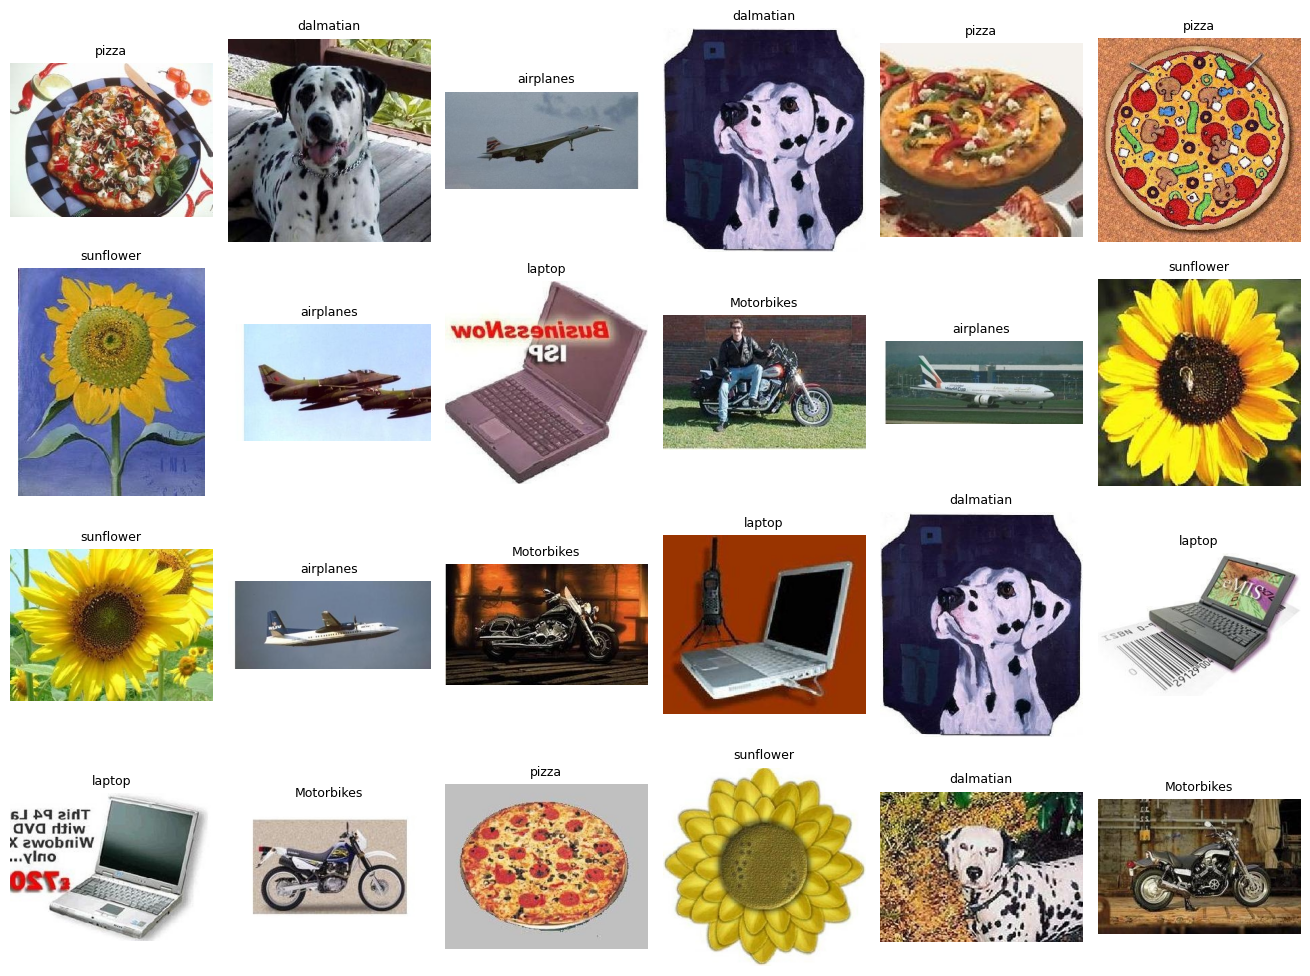

In [5]:
def show_image_grid(df: pd.DataFrame, n: int = 24, cols: int = 6, title_col: str = "label") -> None:
    subset = df.head(min(n, len(df))).copy()
    rows = int(np.ceil(len(subset) / cols))
    plt.figure(figsize=(cols * 2.2, rows * 2.5))

    for i, row in enumerate(subset.itertuples(index=False), start=1):
        plt.subplot(rows, cols, i)
        img = Image.open(row.image_path).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.title(str(getattr(row, title_col)), fontsize=9)

    plt.tight_layout()
    plt.show()


show_image_grid(meta, n=min(24, len(meta)), cols=6)

In [6]:
from pymongo import MongoClient, ASCENDING, UpdateOne
from pymongo.operations import SearchIndexModel

MONGODB_URI = get_env_value("MONGODB_URI", required=True)
MONGODB_DB_NAME = get_env_value("MONGODB_DB_NAME", default="voyage_image_poc")
COLLECTION_NAME = get_env_value("MONGODB_COLLECTION", default="image_embeddings_poc")

EMBEDDING_FIELD = "embedding"
VECTOR_INDEX_NAME = "vector_index_image_embedding"

client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=15000)
client.admin.command("ping")
print("Connected to MongoDB")

db = client[MONGODB_DB_NAME]
collection = db[COLLECTION_NAME]

print(f"Database   : {MONGODB_DB_NAME}")
print(f"Collection : {COLLECTION_NAME}")

# Metadata indexes. MongoDB creates the collection automatically when indexes/documents are created.
collection.create_index([("image_id", ASCENDING)], unique=True, name="uniq_image_id")
collection.create_index([("label", ASCENDING)], name="idx_label")
collection.create_index([("model", ASCENDING)], name="idx_model")
print("Metadata indexes are ready")

Connected to MongoDB
Database   : voyage_image_poc
Collection : image_embeddings_poc
Metadata indexes are ready


In [7]:
def ensure_mongo_vector_search_index() -> bool:
    """Create the Atlas Vector Search index if possible. Local MongoDB will skip this gracefully."""
    vector_index_definition = {
        "fields": [
            {
                "type": "vector",
                "path": EMBEDDING_FIELD,
                "numDimensions": EMBEDDING_DIM,
                "similarity": "cosine",
            },
            {"type": "filter", "path": "label"},
            {"type": "filter", "path": "dataset_name"},
            {"type": "filter", "path": "model"},
        ]
    }

    try:
        existing = list(collection.list_search_indexes(VECTOR_INDEX_NAME))
        if existing:
            print(f"Vector Search index already exists: {VECTOR_INDEX_NAME}")
            return True
    except Exception as exc:
        print("Could not list MongoDB Search indexes. This is expected for local/non-Atlas MongoDB.")
        print("Reason:", repr(exc))
        print("You can still store embeddings and run the Python fallback similarity search.")
        return False

    try:
        index_model = SearchIndexModel(
            definition=vector_index_definition,
            name=VECTOR_INDEX_NAME,
            type="vectorSearch",
        )
        collection.create_search_index(model=index_model)
        print(f"Requested creation of Vector Search index: {VECTOR_INDEX_NAME}")
        return True
    except Exception as exc:
        print("Could not create the MongoDB Atlas Vector Search index automatically.")
        print("Reason:", repr(exc))
        print("If you are using Atlas, create this Vector Search index manually:")
        print(json.dumps({"name": VECTOR_INDEX_NAME, "type": "vectorSearch", "definition": vector_index_definition}, indent=2))
        print("Continuing without failing the notebook. Vector search cell will use Python fallback if needed.")
        return False


def wait_for_mongo_vector_index(max_wait_seconds: int = 180) -> bool:
    start = time.time()
    while time.time() - start < max_wait_seconds:
        try:
            indexes = list(collection.list_search_indexes(VECTOR_INDEX_NAME))
            if not indexes:
                print("Vector Search index not visible yet...")
            else:
                status = indexes[0].get("status")
                print(f"Vector Search index status: {status}")
                if status == "READY":
                    return True
        except Exception as exc:
            print("Skipping index wait because status check failed:", repr(exc))
            return False
        time.sleep(10)
    print("Vector Search index was not READY within the wait window. You can re-run this cell later.")
    return False


vector_index_requested = ensure_mongo_vector_search_index()
if vector_index_requested:
    vector_index_ready = wait_for_mongo_vector_index(max_wait_seconds=120)
else:
    vector_index_ready = False

Requested creation of Vector Search index: vector_index_image_embedding
Vector Search index status: PENDING
Vector Search index status: PENDING
Vector Search index status: PENDING
Vector Search index status: READY


In [8]:
def validate_embedding_matrix(embeddings: np.ndarray) -> np.ndarray:
    embeddings = np.array(embeddings, dtype=np.float32)
    if embeddings.ndim != 2:
        raise RuntimeError(f"Expected a 2D embedding matrix, got shape: {embeddings.shape}")
    if embeddings.shape[1] != EMBEDDING_DIM:
        raise RuntimeError(
            f"Expected embedding dimension {EMBEDDING_DIM}, got {embeddings.shape[1]}. "
            "Update EMBEDDING_DIM and recreate the DB vector index/table if you intentionally changed dimensions."
        )
    return embeddings


def embed_images_with_voyage(meta_subset: pd.DataFrame) -> np.ndarray:
    """Embed only the images passed in. Labels/captions/filenames are NOT sent to Voyage."""
    if meta_subset.empty:
        return np.empty((0, EMBEDDING_DIM), dtype=np.float32)

    import voyageai

    client = voyageai.Client(api_key=VOYAGEAI_API_KEY)
    all_embeddings = []
    paths = meta_subset["image_path"].tolist()

    print(f"Embedding {len(paths)} missing images using {MODEL}...")
    print("This cell calls the Voyage API only for records not already present in DB.")

    for start in range(0, len(paths), BATCH_SIZE):
        batch_paths = paths[start:start + BATCH_SIZE]
        batch_inputs = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB")
            batch_inputs.append([img])  # image only; labels are NOT sent to Voyage

        last_error = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                result = client.multimodal_embed(
                    inputs=batch_inputs,
                    model=MODEL,
                    input_type="document",
                )
                all_embeddings.extend(result.embeddings)
                print(f"Embedded {min(start + len(batch_paths), len(paths))}/{len(paths)}")
                break
            except Exception as exc:
                last_error = exc
                wait = min(20 * attempt, 90)
                print(f"Voyage API attempt {attempt} failed: {repr(exc)}")
                print(f"Waiting {wait} seconds before retry...")
                time.sleep(wait)
        else:
            raise RuntimeError(f"Voyage embedding failed after retries. Last error: {repr(last_error)}")

        if start + BATCH_SIZE < len(paths):
            time.sleep(DELAY_SECONDS_BETWEEN_BATCHES)

    return validate_embedding_matrix(np.array(all_embeddings, dtype=np.float32))


def embed_query_image(image_path: str) -> list[float]:
    """Embed one image as a query vector for similarity search."""
    import voyageai

    client = voyageai.Client(api_key=VOYAGEAI_API_KEY)
    img = Image.open(image_path).convert("RGB")
    result = client.multimodal_embed(
        inputs=[[img]],
        model=MODEL,
        input_type="query",
    )
    emb = np.array(result.embeddings[0], dtype=np.float32)
    if emb.shape[0] != EMBEDDING_DIM:
        raise RuntimeError(f"Expected query dimension {EMBEDDING_DIM}, got {emb.shape[0]}")
    return emb.tolist()

In [9]:
def get_existing_mongo_image_ids(image_ids: list[str]) -> set[str]:
    if not image_ids:
        return set()
    existing = collection.find(
        {"image_id": {"$in": image_ids}, "model": MODEL},
        {"image_id": 1, "_id": 0},
    )
    return {doc["image_id"] for doc in existing}


def store_embeddings_in_mongo(meta_subset: pd.DataFrame, embeddings: np.ndarray) -> None:
    embeddings = validate_embedding_matrix(embeddings)
    if len(meta_subset) != len(embeddings):
        raise RuntimeError("metadata row count and embeddings row count do not match")

    now = datetime.now(timezone.utc)
    operations = []

    for row, emb in zip(meta_subset.itertuples(index=False), embeddings):
        doc = {
            "image_id": row.image_id,
            "dataset_name": row.dataset_name,
            "label_id": int(row.label_id),
            "label": row.label,
            "source_path": row.source_path,
            "image_path": row.image_path,
            "file_name": row.file_name,
            "file_sha256": row.file_sha256,
            "model": MODEL,
            "embedding_dim": int(len(emb)),
            EMBEDDING_FIELD: [float(x) for x in emb],
            "updated_at": now,
            "metadata": {
                "max_image_side": MAX_IMAGE_SIDE,
                "source": "caltech101",
            },
        }
        operations.append(
            UpdateOne(
                {"image_id": row.image_id, "model": MODEL},
                {"$set": doc, "$setOnInsert": {"created_at": now}},
                upsert=True,
            )
        )

    if operations:
        result = collection.bulk_write(operations, ordered=False)
        print(f"MongoDB upsert complete | matched={result.matched_count}, modified={result.modified_count}, upserted={len(result.upserted_ids)}")


existing_ids = get_existing_mongo_image_ids(meta["image_id"].tolist())
missing_meta = meta[~meta["image_id"].isin(existing_ids)].reset_index(drop=True)

print(f"Already in MongoDB: {len(existing_ids)}")
print(f"Missing embeddings : {len(missing_meta)}")

if not missing_meta.empty:
    missing_embeddings = embed_images_with_voyage(missing_meta)
    store_embeddings_in_mongo(missing_meta, missing_embeddings)
else:
    print("No Voyage API call needed. All selected embeddings already exist in MongoDB.")

print("Total documents in collection for this model:", collection.count_documents({"model": MODEL}))

Already in MongoDB: 0
Missing embeddings : 24
Embedding 24 missing images using voyage-multimodal-3.5...
This cell calls the Voyage API only for records not already present in DB.
Embedded 2/24
Embedded 4/24
Embedded 6/24
Voyage API attempt 1 failed: RateLimitError(message='You have not yet added your payment method in the billing page and will have reduced rate limits of 3 RPM and 10K TPM. To unlock our standard rate limits, please add a payment method in the billing page for the appropriate organization in the user dashboard (https://dashboard.voyageai.com/). Even with payment methods entered, the free tokens (200M tokens for Voyage series 3) will still apply. After adding a payment method, you should see your rate limits increase after several minutes. See our pricing docs (https://docs.voyageai.com/docs/pricing) for the free tokens for your model.', http_status=429, request_id=None)
Waiting 20 seconds before retry...
Voyage API attempt 2 failed: RateLimitError(message='You have not

In [10]:
def load_embeddings_from_mongo() -> tuple[pd.DataFrame, np.ndarray]:
    docs = list(collection.find(
        {"image_id": {"$in": meta["image_id"].tolist()}, "model": MODEL},
        {"_id": 0},
    ).sort([("label", ASCENDING), ("image_id", ASCENDING)]))

    if len(docs) != len(meta):
        print(f"Warning: expected {len(meta)} records, loaded {len(docs)} from MongoDB.")

    rows = []
    embeddings = []
    for doc in docs:
        embeddings.append(doc[EMBEDDING_FIELD])
        row = {k: v for k, v in doc.items() if k != EMBEDDING_FIELD}
        rows.append(row)

    stored_df = pd.DataFrame(rows)
    embedding_matrix = validate_embedding_matrix(np.array(embeddings, dtype=np.float32))
    print("Loaded from MongoDB:", stored_df.shape, embedding_matrix.shape)
    display(stored_df[["image_id", "label", "image_path", "model", "embedding_dim"]].head())
    return stored_df, embedding_matrix


stored_df, embeddings = load_embeddings_from_mongo()

Loaded from MongoDB: (23, 13) (23, 1024)


,image_id,label,image_path,model,embedding_dim
0,229e4fbb8cd54f9846abdd59d9e3e324,Motorbikes,voyage_caltech101_db_poc\selected_images\Motor...,voyage-multimodal-3.5,1024
1,7017bab82fc59f3d863036a2ee5c19e8,Motorbikes,voyage_caltech101_db_poc\selected_images\Motor...,voyage-multimodal-3.5,1024
2,7431b1b45a04edb47d6dfdf403c5ac0b,Motorbikes,voyage_caltech101_db_poc\selected_images\Motor...,voyage-multimodal-3.5,1024
3,9f23422e3f8aa940bea43dd9b9085475,Motorbikes,voyage_caltech101_db_poc\selected_images\Motor...,voyage-multimodal-3.5,1024
4,5006927876046d3e88fbee9c468edfa1,airplanes,voyage_caltech101_db_poc\selected_images\airpl...,voyage-multimodal-3.5,1024


In [11]:
def cluster_purity(true_labels, predicted_clusters) -> float:
    df = pd.DataFrame({"true": true_labels, "cluster": predicted_clusters})
    total_correct = 0
    for _, group in df.groupby("cluster"):
        total_correct += group["true"].value_counts().iloc[0]
    return total_correct / len(df)


def run_pca_kmeans(stored_df: pd.DataFrame, embeddings: np.ndarray) -> pd.DataFrame:
    embeddings = validate_embedding_matrix(embeddings)
    X = normalize(embeddings)

    pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
    X_2d = pca_2d.fit_transform(X)

    n_samples = X.shape[0]
    n_clusters = min(len(SELECTED_CLASSES), stored_df["label"].nunique(), n_samples)
    pca_cluster_components = min(12, n_samples - 1, X.shape[1])

    if pca_cluster_components >= 2:
        pca_cluster = PCA(n_components=pca_cluster_components, random_state=RANDOM_SEED)
        X_for_kmeans = normalize(pca_cluster.fit_transform(X))
        print(f"Using PCA-denoised vectors for K-Means: {X_for_kmeans.shape}")
    else:
        X_for_kmeans = X
        print("Skipping PCA denoising because the sample count is too small.")

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)
    cluster_ids = kmeans.fit_predict(X_for_kmeans)

    results = stored_df.copy().reset_index(drop=True)
    results["pca_x"] = X_2d[:, 0]
    results["pca_y"] = X_2d[:, 1]
    results["cluster_id"] = cluster_ids.astype(int)

    print("Cluster metrics")
    print("---------------")
    print(f"Clusters          : {n_clusters}")
    print(f"Purity            : {cluster_purity(results['label'], results['cluster_id']):.4f}")
    print(f"Adjusted Rand     : {adjusted_rand_score(results['label'], results['cluster_id']):.4f}")
    print(f"Normalized MI     : {normalized_mutual_info_score(results['label'], results['cluster_id']):.4f}")
    if 1 < len(set(cluster_ids)) < len(results):
        print(f"Silhouette        : {silhouette_score(X_for_kmeans, cluster_ids):.4f}")

    display(results[["image_id", "label", "cluster_id", "pca_x", "pca_y", "image_path"]].head())
    return results

In [12]:
results = run_pca_kmeans(stored_df, embeddings)

cluster_updates = []
now = datetime.now(timezone.utc)
for row in results.itertuples(index=False):
    cluster_updates.append(
        UpdateOne(
            {"image_id": row.image_id, "model": MODEL},
            {"$set": {
                "cluster_id": int(row.cluster_id),
                "pca_x": float(row.pca_x),
                "pca_y": float(row.pca_y),
                "clustered_at": now,
                "updated_at": now,
            }},
        )
    )

if cluster_updates:
    update_result = collection.bulk_write(cluster_updates, ordered=False)
    print(f"Cluster fields updated in MongoDB: modified={update_result.modified_count}")

Using PCA-denoised vectors for K-Means: (23, 12)
Cluster metrics
---------------
Clusters          : 6
Purity            : 1.0000
Adjusted Rand     : 1.0000
Normalized MI     : 1.0000
Silhouette        : 0.4256


,image_id,label,cluster_id,pca_x,pca_y,image_path
0,229e4fbb8cd54f9846abdd59d9e3e324,Motorbikes,2,0.242180,-0.459734,voyage_caltech101_db_poc\selected_images\Motor...
1,7017bab82fc59f3d863036a2ee5c19e8,Motorbikes,2,0.236054,-0.527953,voyage_caltech101_db_poc\selected_images\Motor...
2,7431b1b45a04edb47d6dfdf403c5ac0b,Motorbikes,2,0.203556,-0.351723,voyage_caltech101_db_poc\selected_images\Motor...
3,9f23422e3f8aa940bea43dd9b9085475,Motorbikes,2,0.134749,-0.446563,voyage_caltech101_db_poc\selected_images\Motor...
4,5006927876046d3e88fbee9c468edfa1,airplanes,5,0.322623,0.203470,voyage_caltech101_db_poc\selected_images\airpl...


Cluster fields updated in MongoDB: modified=23


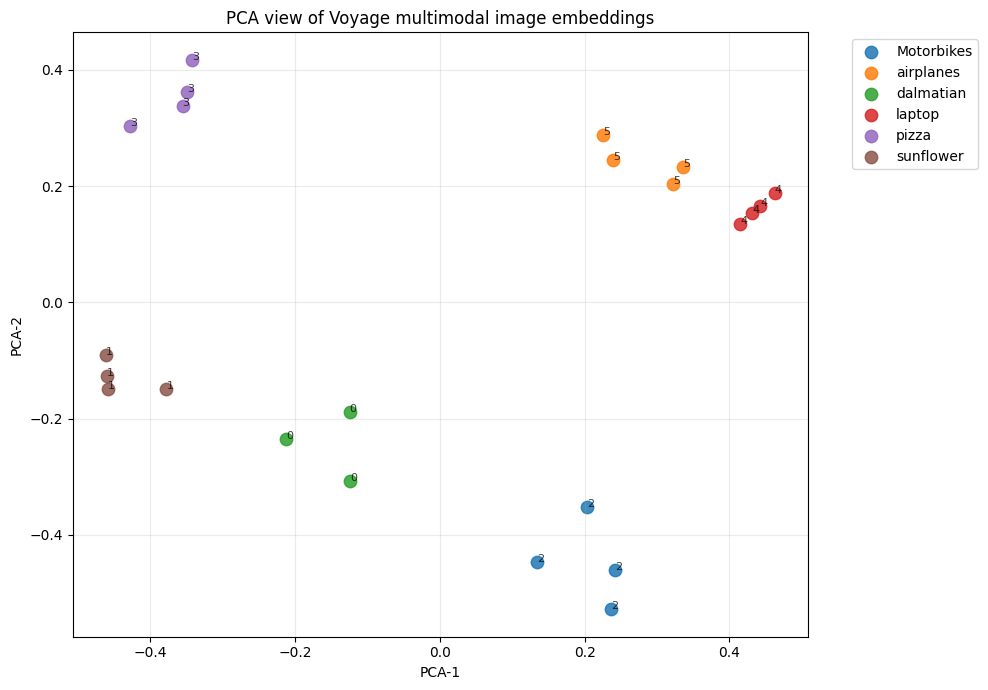


Cluster 0 | label mix: {'dalmatian': 3}


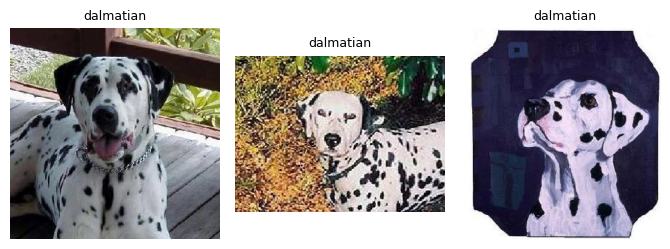


Cluster 1 | label mix: {'sunflower': 4}


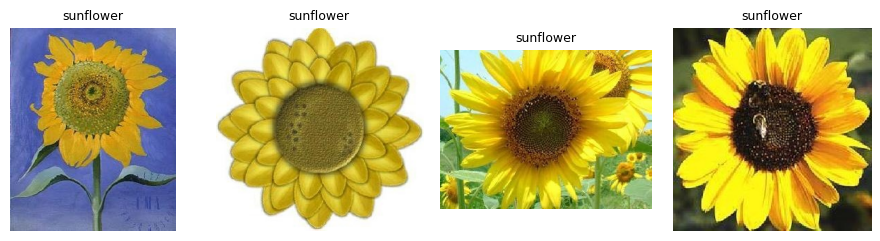


Cluster 2 | label mix: {'Motorbikes': 4}


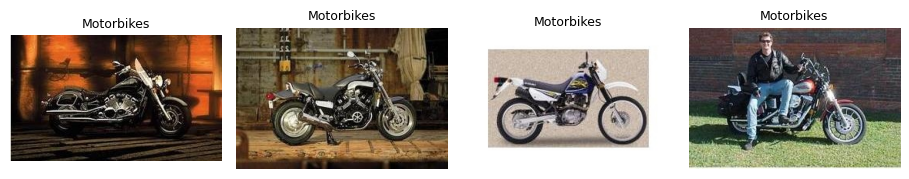


Cluster 3 | label mix: {'pizza': 4}


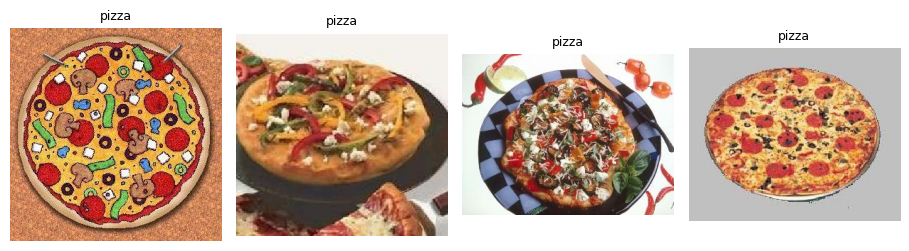


Cluster 4 | label mix: {'laptop': 4}


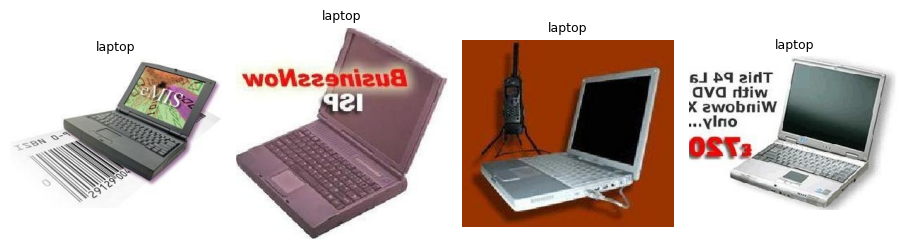


Cluster 5 | label mix: {'airplanes': 4}


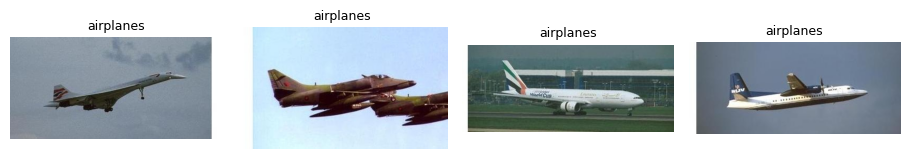

In [13]:
def plot_pca_results(results: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 7))
    for label, group in results.groupby("label"):
        plt.scatter(group["pca_x"], group["pca_y"], label=label, s=80, alpha=0.85)

    for row in results.itertuples():
        plt.text(row.pca_x, row.pca_y, str(row.cluster_id), fontsize=8, alpha=0.75)

    plt.title("PCA view of Voyage multimodal image embeddings")
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def show_cluster_images(results: pd.DataFrame, max_per_cluster: int = 8) -> None:
    for cluster in sorted(results["cluster_id"].unique()):
        group = results[results["cluster_id"] == cluster].head(max_per_cluster)
        cols = min(4, len(group))
        rows = int(np.ceil(len(group) / cols))

        label_counts = group["label"].value_counts().to_dict()
        print(f"\nCluster {cluster} | label mix: {label_counts}")

        plt.figure(figsize=(cols * 2.3, rows * 2.5))
        for i, row in enumerate(group.itertuples(index=False), start=1):
            plt.subplot(rows, cols, i)
            img = Image.open(row.image_path).convert("RGB")
            plt.imshow(img)
            plt.axis("off")
            plt.title(str(row.label), fontsize=9)
        plt.tight_layout()
        plt.show()


plot_pca_results(results)
show_cluster_images(results)

Query image label: Motorbikes


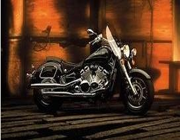

In [14]:
def python_cosine_search(query_embedding: list[float], stored_df: pd.DataFrame, embeddings: np.ndarray, top_k: int = 5) -> pd.DataFrame:
    q = normalize(np.array(query_embedding, dtype=np.float32).reshape(1, -1))
    X = normalize(validate_embedding_matrix(embeddings))
    scores = (X @ q.T).ravel()
    order = np.argsort(scores)[::-1][:top_k]
    out = stored_df.iloc[order].copy()
    out["score"] = scores[order]
    return out[["image_id", "label", "cluster_id", "score", "image_path"]]


def mongo_vector_search(query_embedding: list[float], top_k: int = 5, label_filter: Optional[str] = None) -> list[dict]:
    count = collection.count_documents({"model": MODEL})
    num_candidates = min(max(top_k * 20, 50), max(count, top_k))

    vector_search_stage = {
        "index": VECTOR_INDEX_NAME,
        "path": EMBEDDING_FIELD,
        "queryVector": [float(x) for x in query_embedding],
        "numCandidates": num_candidates,
        "limit": top_k,
    }
    filter_doc = {"model": MODEL}
    if label_filter:
        filter_doc["label"] = label_filter
    vector_search_stage["filter"] = filter_doc

    pipeline = [
        {"$vectorSearch": vector_search_stage},
        {"$project": {
            "score": {"$meta": "vectorSearchScore"},
            "image_id": 1,
            "label": 1,
            "cluster_id": 1,
            "pca_x": 1,
            "pca_y": 1,
            "image_path": 1,
        }},
    ]
    return list(collection.aggregate(pipeline))


# Demo: use one existing image as a query image.
query_row = stored_df.iloc[0]
query_embedding = embed_query_image(query_row["image_path"])
print("Query image label:", query_row["label"])
Image.open(query_row["image_path"]).resize((180, 140))

In [15]:
try:
    mongo_hits = mongo_vector_search(query_embedding, top_k=5)
    print("MongoDB Atlas Vector Search results")
    display(pd.DataFrame(mongo_hits))
except Exception as exc:
    print("MongoDB Atlas Vector Search was not available, so using Python cosine fallback.")
    print("Reason:", repr(exc))
    fallback_hits = python_cosine_search(query_embedding, stored_df, embeddings, top_k=5)
    display(fallback_hits)

MongoDB Atlas Vector Search results


,_id,image_id,image_path,label,cluster_id,pca_x,pca_y,score
0,69fc79fe7b4d1d037ec2d899,229e4fbb8cd54f9846abdd59d9e3e324,voyage_caltech101_db_poc\selected_images\Motor...,Motorbikes,2,0.242180,-0.459734,0.952567
1,69fc79fe7b4d1d037ec2d8a1,7017bab82fc59f3d863036a2ee5c19e8,voyage_caltech101_db_poc\selected_images\Motor...,Motorbikes,2,0.236054,-0.527953,0.856223
2,69fc79fe7b4d1d037ec2d89d,7431b1b45a04edb47d6dfdf403c5ac0b,voyage_caltech101_db_poc\selected_images\Motor...,Motorbikes,2,0.203556,-0.351723,0.741379
3,69fc79fe7b4d1d037ec2d894,9f23422e3f8aa940bea43dd9b9085475,voyage_caltech101_db_poc\selected_images\Motor...,Motorbikes,2,0.134749,-0.446563,0.725052
4,69fc79fe7b4d1d037ec2d88d,5006927876046d3e88fbee9c468edfa1,voyage_caltech101_db_poc\selected_images\airpl...,airplanes,5,0.322623,0.203470,0.618905


## Notes

The MongoDB collection stores the embeddings as an array of floats in the `embedding` field. If Atlas Vector Search is not available, the notebook still stores the data and uses a Python cosine-similarity fallback for the final search demo.